<a href="https://colab.research.google.com/github/pp24aaq/Msc-DataScience-Project/blob/main/Fake_News_Research_Project_Poojitha.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install textstat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 14.1 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
path = '/content/drive/MyDrive/Fake.csv'
path = '/content/drive/MyDrive/True.csv'

In [4]:
import os
os.listdir('/content/drive/MyDrive')

['Colab Notebooks',
 'new resume1.pdf',
 'abhishek.csv.pdf',
 'spark-3.3.0-bin-hadoop3.tgz',
 'housing.csv',
 'AmazonBooks-1.csv',
 'all-weeks-countries-1.csv',
 'Poojitha P_copy (1).pdf',
 'Poojitha P_copy.pdf',
 'Multimodal_IMDB_dataset',
 'label-78155403900_copy.pdf',
 'True.csv',
 'Fake.csv',
 'Saved from Chrome',
 'Customer_Churn_Data_Large.xlsx']

In [5]:
import pandas as pd
import numpy as np
Fake_path = '/content/drive/MyDrive/Fake.csv'
True_path = '/content/drive/MyDrive/True.csv'
df_fake = pd.read_csv(Fake_path)
df_real = pd.read_csv(True_path)

print("fake news data:")
print(df_fake.head())

print("real news data:")
print(df_real.head())

# df_real.head()

fake news data:
                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   
3   Trump Is So Obsessed He Even Has Obama’s Name...   
4   Pope Francis Just Called Out Donald Trump Dur...   

                                                text subject  \
0  Donald Trump just couldn t wish all Americans ...    News   
1  House Intelligence Committee Chairman Devin Nu...    News   
2  On Friday, it was revealed that former Milwauk...    News   
3  On Christmas day, Donald Trump announced that ...    News   
4  Pope Francis used his annual Christmas Day mes...    News   

                date  
0  December 31, 2017  
1  December 31, 2017  
2  December 30, 2017  
3  December 29, 2017  
4  December 25, 2017  
real news data:
                                               title  \
0  As U.S. budget fight looms, Republicans flip t...

In [6]:
df_fake.info()
df_real.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
dtypes: object(4)
memory usage: 733.9+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
dtypes: object(4)
memory usage: 669.4+ KB


In [7]:
# labelling the data as fake(1) and real(0) so we can contatenate into a single dataframe
df_fake['label'] = 1
df_real['label'] = 0

df = pd.concat([df_fake, df_real], ignore_index=True)

# Shufflling the dataset to mix fake and real news rows
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# df.head()

In [8]:
import numpy as np

# Checking and clearing any missing values

# # Dropping the 'date' and 'subject' columns since date is irrelevant to our methodology and subject is vague and irrelevant
#df.drop(['date','subject'],axis=1, inplace=True)

print(f"Size before dropping rows with empty values: {len(df)} rows")

# replace all empty strings with NaN and dropping those rows.
df['text'].replace(r'^\s*$', np.nan, regex=True, inplace=True)
df['title'].replace(r'^\s*$', np.nan, regex=True, inplace=True)
df.dropna(inplace=True)
print(f"Size after dropping empty rows: {len(df)} rows")

# df.head()

Size before dropping rows with empty values: 44898 rows
Size after dropping empty rows: 44267 rows


/tmp/ipython-input-1126617364.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['text'].replace(r'^\s*$', np.nan, regex=True, inplace=True)
/tmp/ipython-input-1126617364.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

--- REVISION ---

**Data leakage concerns**

While the high accuracy of initial models were too good to be true, the underlying cause as highlighted by the project supervisior are valid. Upon further inspection, artifacts were found in the real dataset like the words "Reuters", "produced by", the name of the post were found or pieces of html that were accidentally scraped off the websites.

Since this might skew our model towards news that simply has that one attribute right, I'll be taking a revised approach where I scrape all occurences of such terms from the dataset and retrain the models.

In [9]:
import re

def clean_text(text):
    text = str(text)

    # removing common starting phrases
    text = re.sub(r"^.*?\(Reuters\)\s*-\s*", "", text)
    text = re.sub(r"^.*?21st Century Wire says", "", text)

    # removing common footers, links and html
    text = re.sub(r"\s*--\s*Source link:.*$", "", text)
    text = re.sub(r"Reporting by.*$", "", text)
    text = re.sub(r"WORK BY SUBSCRIBING.*$", "", text)
    text = re.sub(r"SUPPORT 21WIRE.*$", "", text)
    text = re.sub(r"Featured image via.*$", "", text)
    text = re.sub(r"https?://\S+|www\.\S+", "", text)
    text = re.sub(r"@[A-Za-z0-9_]+", "", text)
    text = re.sub(r"<.*?>", "", text)

    return text

df['text'] = df['text'].apply(clean_text)

# removing rows with empty values after artifact cleanup
df['text'].replace(r'^\s*$', np.nan, regex=True, inplace=True)
df['title'].replace(r'^\s*$', np.nan, regex=True, inplace=True)
df.dropna(inplace=True)

df.head()

/tmp/ipython-input-1131369188.py:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['text'].replace(r'^\s*$', np.nan, regex=True, inplace=True)
/tmp/ipython-input-1131369188.py:26: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"Ben Stein, reputable professor from, Pepperdi...",US_News,"February 13, 2017",1
1,Trump drops Steve Bannon from National Securit...,U.S. President Donald Trump removed his chief ...,politicsNews,"April 5, 2017",0
2,Puerto Rico expects U.S. to lift Jones Act shi...,Puerto Rico Governor Ricardo Rossello said on ...,politicsNews,"September 27, 2017",0
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",1
4,Donald Trump heads for Scotland to reopen a go...,Most U.S. presidential candidates go abroad to...,politicsNews,"June 24, 2016",0


In [10]:
import string
import textstat
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Download the VADER lexicon if not already downloaded
nltk.download('vader_lexicon')

# --- Length-based Features ---
# Character count of the title
df['title_char_count'] = df['title'].str.len()

# Word count of the text
df['text_word_count'] = df['text'].apply(lambda x: len(str(x).split()))

# --- Stylistic Features ---
# Ratio of uppercase characters in the title (a proxy for sensationalism)
def uppercase_ratio(text):
    # Avoid division by zero for empty strings
    num_chars = sum(1 for char in text if char.isalpha())
    if num_chars == 0:
        return 0
    num_uppercase = sum(1 for char in text if char.isupper())
    return num_uppercase / num_chars

df['title_caps_ratio'] = df['title'].apply(uppercase_ratio)

# Readability of the text using Flesch Reading Ease score, clipped to 0 to 100 range as majority of samples are too short
df['text_readability'] = df['text'].apply(textstat.flesch_reading_ease)
df['text_readability'] = df['text_readability'].clip(lower=0, upper=100)

# --- Sentiment Features ---
sid = SentimentIntensityAnalyzer()

# Get sentiment scores for the title
df['title_sentiment'] = df['title'].apply(lambda x: sid.polarity_scores(x)['compound'])

# Get sentiment scores for the text
df['text_sentiment'] = df['text'].apply(lambda x: sid.polarity_scores(x)['compound'])


print("DF with updated columns")
df.head()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


DF with updated columns


,title,text,subject,date,label,title_char_count,text_word_count,title_caps_ratio,text_readability,title_sentiment,text_sentiment
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"Ben Stein, reputable professor from, Pepperdi...",US_News,"February 13, 2017",1,89,159,0.140845,40.533726,0.2732,-0.4939
1,Trump drops Steve Bannon from National Securit...,U.S. President Donald Trump removed his chief ...,politicsNews,"April 5, 2017",0,55,768,0.125000,39.789744,0.3400,0.9880
2,Puerto Rico expects U.S. to lift Jones Act shi...,Puerto Rico Governor Ricardo Rossello said on ...,politicsNews,"September 27, 2017",0,64,302,0.113208,50.411974,0.0000,-0.6699
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",1,89,179,0.256757,42.260360,-0.1531,-0.4215
4,Donald Trump heads for Scotland to reopen a go...,Most U.S. presidential candidates go abroad to...,politicsNews,"June 24, 2016",0,55,525,0.065217,48.894396,0.0000,0.9161


In [11]:
# Combining the title and text into a new column called 'full_text'
df['full_text'] = df['title'] + " " + df['text']

# We can now drop the original 'title' and 'text' columns
# df.drop(['title', 'text'], axis=1, inplace=True)

print("Created 'full_text' column.")
df.head()

Created 'full_text' column.


,title,text,subject,date,label,title_char_count,text_word_count,title_caps_ratio,text_readability,title_sentiment,text_sentiment,full_text
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"Ben Stein, reputable professor from, Pepperdi...",US_News,"February 13, 2017",1,89,159,0.140845,40.533726,0.2732,-0.4939,Ben Stein Calls Out 9th Circuit Court: Committ...
1,Trump drops Steve Bannon from National Securit...,U.S. President Donald Trump removed his chief ...,politicsNews,"April 5, 2017",0,55,768,0.125000,39.789744,0.3400,0.9880,Trump drops Steve Bannon from National Securit...
2,Puerto Rico expects U.S. to lift Jones Act shi...,Puerto Rico Governor Ricardo Rossello said on ...,politicsNews,"September 27, 2017",0,64,302,0.113208,50.411974,0.0000,-0.6699,Puerto Rico expects U.S. to lift Jones Act shi...
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",1,89,179,0.256757,42.260360,-0.1531,-0.4215,OOPS: Trump Just Accidentally Confirmed He Le...
4,Donald Trump heads for Scotland to reopen a go...,Most U.S. presidential candidates go abroad to...,politicsNews,"June 24, 2016",0,55,525,0.065217,48.894396,0.0000,0.9161,Donald Trump heads for Scotland to reopen a go...


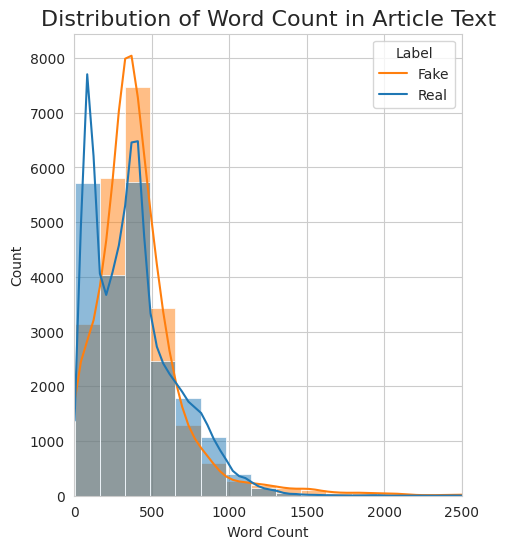

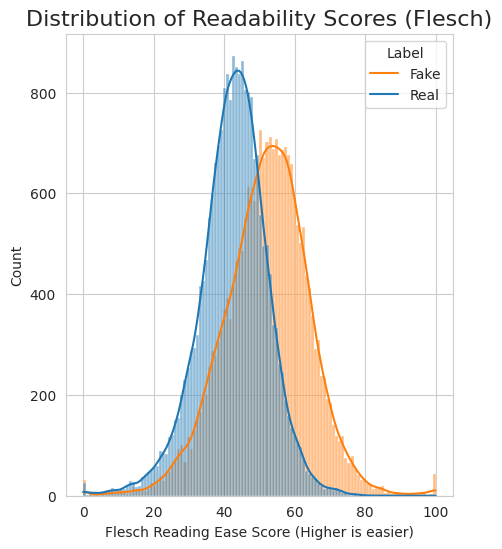

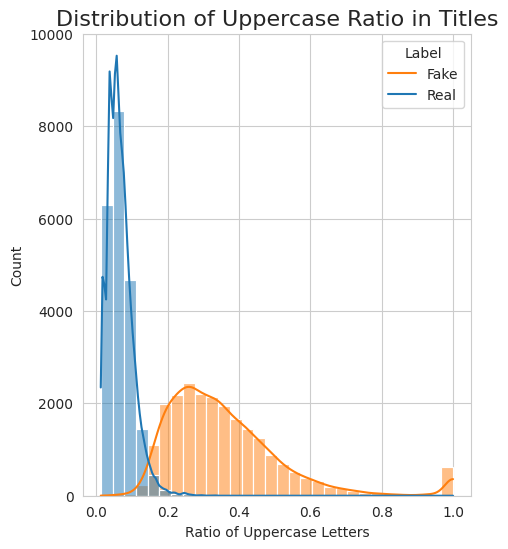

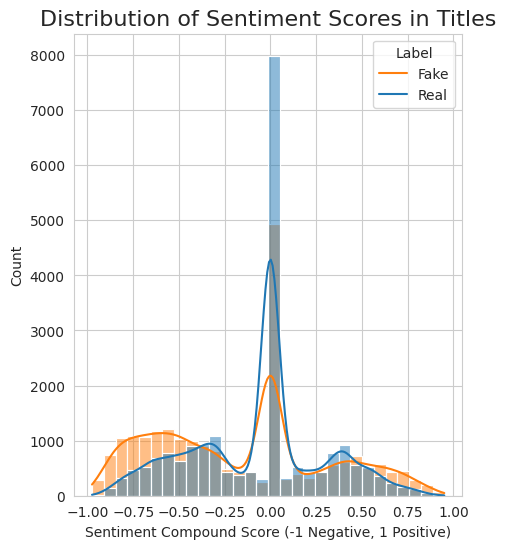

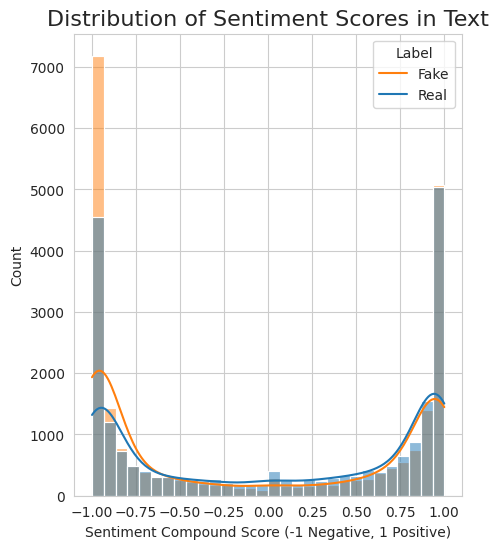

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a nice style for the plots
sns.set_style("whitegrid")

# Plot 1: Word Count of the Article Text
plt.figure(figsize=(5, 6))
sns.histplot(data=df, x='text_word_count', hue='label', bins=50, kde=True)
plt.title('Distribution of Word Count in Article Text', fontsize=16)
plt.xlabel('Word Count')
plt.legend(title='Label', labels=['Fake', 'Real'])
# Limit x-axis for better readability as some articles might be extremely long
plt.xlim(0, 2500)
plt.show()

# Plot 2: Readability Score of the Article Text
plt.figure(figsize=(5, 6))
sns.histplot(data=df, x='text_readability', hue='label', kde=True)
plt.title('Distribution of Readability Scores (Flesch)', fontsize=16)
plt.xlabel('Flesch Reading Ease Score (Higher is easier)')
plt.legend(title='Label', labels=['Fake', 'Real'])
plt.show()

# Plot 3: Uppercase Ratio in Titles
plt.figure(figsize=(5, 6))
sns.histplot(data=df, x='title_caps_ratio', hue='label', bins=30, kde=True)
plt.title('Distribution of Uppercase Ratio in Titles', fontsize=16)
plt.xlabel('Ratio of Uppercase Letters')
plt.legend(title='Label', labels=['Fake', 'Real'])
plt.show()

# Plot 4: Sentiment of Titles
plt.figure(figsize=(5, 6))
sns.histplot(data=df, x='title_sentiment', hue='label', bins=30, kde=True)
plt.title('Distribution of Sentiment Scores in Titles', fontsize=16)
plt.xlabel('Sentiment Compound Score (-1 Negative, 1 Positive)')
plt.legend(title='Label', labels=['Fake', 'Real'])
plt.show()

# Plot 5: Sentiment of Text
plt.figure(figsize=(5, 6))
sns.histplot(data=df, x='text_sentiment', hue='label', bins=30, kde=True)
plt.title('Distribution of Sentiment Scores in Text', fontsize=16)
plt.xlabel('Sentiment Compound Score (-1 Negative, 1 Positive)')
plt.legend(title='Label', labels=['Fake', 'Real'])
plt.show()

**Key takeaways from the initial exploration:**

**Title Uppercase Ratio:** Strongest inidcator. Real news titles consistently avoid heavy capitalization, while fake news titles frequently use a high ratio of capital letters, with a notable spike to serve as "clickbait".

**Title Sentiment:** Real news headlines are overwhelmingly neutral (a sharp peak at 0.0 sentiment). Fake news headlines are much more likely to be emotionally charged, showing spikes in both extreme positive and extreme negative sentiment.

**Text Sentiment:** The body of fake news articles is overwhelmingly negative in tone (a massive spike at -1.0). In contrast, the body of the real news articles shows a strong positive sentiment (a large spike at +1.0).

**Text Word Count:** Fake news articles in this dataset tend to be shorter, with their lengths clustered tightly around 400-500 words. Real news articles are, on average, longer and have a much wider and more varied word count.

**Readability (Text):** Fake news articles are generally written in simpler, easier-to-read language (peaking at a higher Flesch score of ~55). Real news articles tend to be more linguistically complex (peaking at a lower score of ~45).


In [13]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from scipy.sparse import hstack  # Used to combine feature matrices
import matplotlib.pyplot as plt

# 1. Defining our numerical and text features from earlier steps
numerical_features = df[[
    # 'title_caps_ratio' # not used for the models due to aforementioned reasons
    'title_sentiment',
    'text_word_count',
    'text_readability',
    'text_sentiment'
]]

# Defining the target variable
y = df['label']

# 2. Vectorizing the text columns
# Clearing out stop words and converting to lowercase

# 'text' column
# max_features=5000, keeping at most 5000 common words (reasonable estimate based on our dataset)
tfidf_text = TfidfVectorizer(stop_words='english', max_features=5000, min_df=5)
X_text_tfidf = tfidf_text.fit_transform(df['text'])

# 'title' column
# fewer features(1000) cause its shorter
tfidf_title = TfidfVectorizer(stop_words='english', max_features=1000, min_df=5)
X_title_tfidf = tfidf_title.fit_transform(df['title'])

# 3. Create our Two Final Feature Sets

# X_text_only: Combining 'text' and 'title' TF-IDF matrices for Naive Bayes
X_text_only = hstack([X_text_tfidf, X_title_tfidf])

# X_hybrid: Combine text TF-IDF matrices and the 5 numerical features for the other models
X_hybrid = hstack([X_text_tfidf, X_title_tfidf, numerical_features.values])

print("Feature preparation complete!")
print(f"Shape of text-only features: {X_text_only.shape}")
print(f"Shape of hybrid features: {X_hybrid.shape}")

Feature preparation complete!
Shape of text-only features: (44183, 6000)
Shape of hybrid features: (44183, 6004)


In [14]:
# 80/20 train/test split for the TEXT ONLY
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text_only, y, test_size=0.2, random_state=42
)

# 80/20 train/test split for the data with additional parameters
# also using the same 'random_state=42' to ensure the splits are identical
X_train_hybrid, X_test_hybrid, y_train_hybrid, y_test_hybrid = train_test_split(
    X_hybrid, y, test_size=0.2, random_state=42
)

print("Done splitting data.")

Done splitting data.


In [15]:
# To evaluate based on just the body text alone
print("Model 1: Multinomial Naive Bayes")

# 1. Initializing the model
nb_model = MultinomialNB()

# 2. Training the model
nb_model.fit(X_train_text, y_train)

# 3. predicting...
nb_preds = nb_model.predict(X_test_text)

# 4. Model evaluation
nb_accuracy = accuracy_score(y_test, nb_preds)
print(f"Accuracy: {nb_accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, nb_preds, target_names=['Real', 'Fake']))

Model 1: Multinomial Naive Bayes
Accuracy: 93.60%

Classification Report:
              precision    recall  f1-score   support

        Real       0.94      0.92      0.93      4331
        Fake       0.93      0.95      0.94      4506

    accuracy                           0.94      8837
   macro avg       0.94      0.94      0.94      8837
weighted avg       0.94      0.94      0.94      8837



In [19]:
# To evaluate while considering the additional attributes that we engineered
print("\nModel 2: Logistic Regression")

# 1. Setting up a parameter grid
# We'll be testing different regularization strengths (C), basically how easily the model accepts a feature
lr_params = {
    'C': [10**i for i in range(-3,4)],
    'solver': ['liblinear']
}
# 2. Initializing Grid Search
# cv=3 means it validates 3 times for each combo to be sure
grid_lr = GridSearchCV(LogisticRegression(max_iter=1000), lr_params, cv=3, n_jobs=-1)

# 3. Training the model
grid_lr.fit(X_train_hybrid, y_train_hybrid)
lr_params_results = pd.DataFrame(grid_lr.cv_results_)
formatted_params_result = lr_params_results[['params', 'mean_test_score', 'std_test_score', 'rank_test_score', 'mean_fit_time', 'std_fit_time']]
print(formatted_params_result)
print(f"Best Parameters Found: {grid_lr.best_params_}")

# 4. predicting using the BEST weights found...
lr_preds = grid_lr.predict(X_test_hybrid)

# 5. Model evaluation
lr_accuracy = accuracy_score(y_test_hybrid, lr_preds)
print(f"Accuracy: {lr_accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test_hybrid, lr_preds, target_names=['Real', 'Fake']))

# 6. Training Accuracy check for Overfitting
lr_train_preds = grid_lr.predict(X_train_hybrid)
lr_train_acc = accuracy_score(y_train_hybrid, lr_train_preds)
print(f"Training Accuracy: {lr_train_acc * 100:.2f}%")


Model 2: Logistic Regression
                                params  mean_test_score  std_test_score  \
0  {'C': 0.001, 'solver': 'liblinear'}         0.715781        0.002576   
1   {'C': 0.01, 'solver': 'liblinear'}         0.892576        0.001421   
2    {'C': 0.1, 'solver': 'liblinear'}         0.964890        0.000262   
3      {'C': 1, 'solver': 'liblinear'}         0.982601        0.000661   
4     {'C': 10, 'solver': 'liblinear'}         0.986307        0.000212   
5    {'C': 100, 'solver': 'liblinear'}         0.986165        0.000183   
6   {'C': 1000, 'solver': 'liblinear'}         0.986024        0.000174   

   rank_test_score  mean_fit_time  std_fit_time  
0                7       1.810715      0.198253  
1                6       1.839688      0.255741  
2                5       2.247312      0.115139  
3                4       2.791166      0.043140  
4                1       4.182990      0.349960  
5                2       3.193256      0.490052  
6                3 

In [21]:
# Similar to LR, considers the additional attributes that we engineered
print("\nModel 3: Decision Tree")

# 1. Setting up the parameter grid
# We test different depths and splitting criteria to find the best balance
dt_params = {
    'max_depth': [10, 20, 30, None],       # 'None' here, just in case its feasible to grow until leaves are pure
    'min_samples_split': [5, 10, 20],      # Minimum samples required to split a node
    'criterion': ['gini', 'entropy']
}

# 2. Initializing Grid Search
# cv=3 means it validates 3 times for each combination
grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_params, cv=3, n_jobs=-1)

# 3. Training the model
grid_dt.fit(X_train_hybrid, y_train_hybrid)
grid_params_results = pd.DataFrame(grid_dt.cv_results_)
formatted_params_result = grid_params_results[['params', 'mean_test_score', 'std_test_score', 'rank_test_score', 'mean_fit_time', 'std_fit_time']]
print(formatted_params_result)
print(f"Best Parameters Found: {grid_dt.best_params_}")

# 4. predicting...
dt_preds = grid_dt.predict(X_test_hybrid)

# 5. Model evaluation
dt_accuracy = accuracy_score(y_test_hybrid, dt_preds)
print(f"\nAccuracy: {dt_accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test_hybrid, dt_preds, target_names=['Real', 'Fake']))

# 6. Training Accuracy check for Overfitting
dt_train_preds = grid_dt.predict(X_train_hybrid)
dt_train_acc = accuracy_score(y_train_hybrid, dt_train_preds)
print(f"Training Accuracy: {dt_train_acc * 100:.2f}%")


Model 3: Decision Tree
                                               params  mean_test_score  \
0   {'criterion': 'gini', 'max_depth': 10, 'min_sa...         0.920076   
1   {'criterion': 'gini', 'max_depth': 10, 'min_sa...         0.919821   
2   {'criterion': 'gini', 'max_depth': 10, 'min_sa...         0.919510   
3   {'criterion': 'gini', 'max_depth': 20, 'min_sa...         0.932072   
4   {'criterion': 'gini', 'max_depth': 20, 'min_sa...         0.931675   
5   {'criterion': 'gini', 'max_depth': 20, 'min_sa...         0.929865   
6   {'criterion': 'gini', 'max_depth': 30, 'min_sa...         0.932496   
7   {'criterion': 'gini', 'max_depth': 30, 'min_sa...         0.932354   
8   {'criterion': 'gini', 'max_depth': 30, 'min_sa...         0.931138   
9   {'criterion': 'gini', 'max_depth': None, 'min_...         0.927941   
10  {'criterion': 'gini', 'max_depth': None, 'min_...         0.927234   
11  {'criterion': 'gini', 'max_depth': None, 'min_...         0.927177   
12  {'criterio

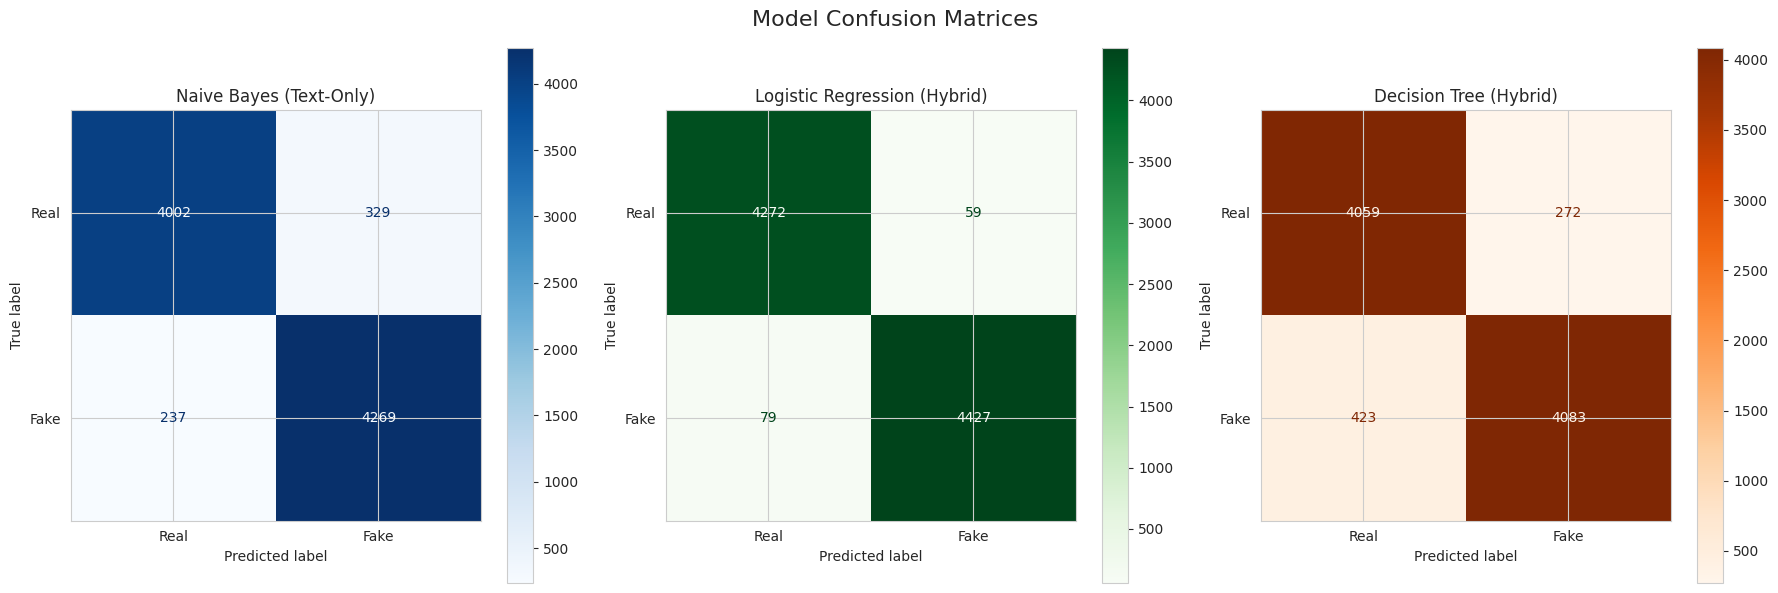

In [23]:
# Set up a figure to plot all three results
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Model Confusion Matrices', fontsize=16)

# Naive Bayes Plot
ConfusionMatrixDisplay.from_estimator(nb_model, X_test_text, y_test,
                                      display_labels=['Real', 'Fake'],
                                      cmap='Blues', ax=axes[0])
axes[0].set_title('Naive Bayes (Text-Only)')

# Logistic Regression Plot
ConfusionMatrixDisplay.from_estimator(lr_model, X_test_hybrid, y_test_hybrid,
                                      display_labels=['Real', 'Fake'],
                                      cmap='Greens', ax=axes[1])
axes[1].set_title('Logistic Regression (Hybrid)')

# Decision Tree Plot
ConfusionMatrixDisplay.from_estimator(dt_model, X_test_hybrid, y_test_hybrid,
                                      display_labels=['Real', 'Fake'],
                                      cmap='Oranges', ax=axes[2])
axes[2].set_title('Decision Tree (Hybrid)')

plt.tight_layout()
plt.show()

So, to answer the questions we began with,

**Q. What are the key features of real and fake news?**
Based on the Exploratory Data Analysis (EDA) we can gather enough evidence to conclude that every article has its own digital fingerprint. Following are the metrics that I used to establish this fact:

**Uppercase Ratio:** Fake news titles use far more capitalization for sensationalism, while real news titles are almost always in standard sentence case.

**Title Sentiment:** Real news headlines are overwhelmingly neutral. Fake news headlines are much more likely to be emotionally charged (both very positive and very negative).

**Text Sentiment _(UPDATE)_:** The body of fake news articles is overwhelmingly negative. In contrast, the body of real news articles is **on an average, neutral.**

**Word Count:** Fake news articles tend to be shorter and more uniform in length, clustering around 400-500 words. Real news articles have a much wider variety of lengths and are, on average, longer.

**Readability:** Fake news is written in simpler, easier-to-read language (higher Flesch score) than the more complex, formal language of real news (lower Flesch score).

**Q. Which simple techniques work best to classify news articles?**
Based on our modelling approach we can arrive at the following conclusion:

The "Hybrid" Approach: The most important finding is that the models using the hybrid features (Logistic Regression and Decision Tree) performed dramatically better (94.3%+) than the model using only text (Naive Bayes at 93.6%).

**UPDATE** _Note on LR: While LR is generally good at recognizing patterns in large text data, content like fake news can at points be manipulated to retain such patterns from their real counterparts. Therefore, while being more computationally expensive, Decision Trees offer a slight buffer against such faking practises._

How an article is written (its style, sentiment, and length) is a more powerful predictor of it being real or fake than what's actually written.

***Overall Interpretation:*** Because these models had access to our 4 engineered features, they could learn simple, powerful rules. This means models built over principles like such are much more capable of weeding out real and fake news to a respectable degree. While the parameters we've used are subject to change, the approach would remain the same and can be tweaked in a relatively short time. This is also much more resource efficient than using modern day LLMs with access to web browsing abilities, therefore making our approach and ideal initial screening method to detect and process fake news.